# ST-GCN: Spatial Temporal Graph Convolutional Network

In [41]:
# Librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

# Implementación de la arquitectura

## Definición de la Capa de Convolución Espacial (GCN)

In [42]:
class SpatialGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A_partitions):
        super().__init__()
        self.K = len(A_partitions)  # Número de particiones (K=3)
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=1) 
            for _ in range(self.K)
        ])
        self.register_buffer('A', A_partitions) # A_partitions es la matriz A normalizada

    def forward(self, x):
        # x tiene forma (N, C_in, T, V), donde V=33 (keypoints)
        output = None
        for k in range(self.K):
            # 1. Multiplicación del feature map por la matriz A_k
            # torch.einsum realiza (N, C_in, T, V) @ (V, V) -> (N, C_in, T, V)
            # donde V x V es la matriz A_k (aplicando la adyacencia)
            x_neighbor = torch.einsum('nctv,vw->nctw', (x, self.A[k]))
            
            # 2. Convolución 1x1 (aplicando W_k)
            z = self.convs[k](x_neighbor) 

            # 3. Sumar los resultados de las K particiones
            output = z if output is None else output + z
        
        return output

## Definición de la Capa de Convolución Temporal (TCN)

In [43]:
class STGCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, A_partitions):
        super().__init__()
        
        T_kernel, V_kernel = kernel_size # V_kernel siempre será 1

        # Módulo de Convolución Espacial
        self.gcn = SpatialGraphConv(out_channels, out_channels, A_partitions)
        
        # Convolución Temporal 2D (solo en el eje del tiempo)
        self.tcn = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=(T_kernel, 1), 
            padding=(T_kernel // 2, 0)
        )
        
        
        # Capa residual para la conexión skip
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # x tiene forma (N, C_in, T, V)

        # 1. Conexión Residual
        res = self.residual(x)

        # 2. Módulo TCN (Temporal)
        tcn_out = self.tcn(x) # tcn_out tiene forma (N, C_out, T, V)
        tcn_out = nn.ReLU()(tcn_out)
        
        # 3. Módulo GCN (Espacial)
        # El GCN ahora recibe los features temporales procesados
        st_out = self.gcn(tcn_out)
        
        # 4. SUMA FINAL
        return nn.ReLU()(st_out + res)

In [44]:
class STGCN_Model(nn.Module):
    def __init__(self, num_classes, A_partitions):
        super().__init__()
        
        # Parámetros fijos para MediaPipe Pose (x, y)
        self.C = 2 # Coordenadas x, y
        self.V = 33 # Keypoints/Nodos
        
        # El resto de la arquitectura STGCN sigue igual
        # Asumimos que el primer bloque STGCN recibe 2 canales (x, y)
        self.st_gcn_stack = nn.Sequential(
            STGCN_Block(self.C, 64, (9, 1), A_partitions),
            STGCN_Block(64, 64, (9, 1), A_partitions),
            STGCN_Block(64, 128, (9, 1), A_partitions),
            # ... otros bloques ...
        )

        self.out_channels = 128 
        self.classifier = nn.Linear(self.out_channels, num_classes)

    # ----------------------------------------------------
    # MÉTODOS PRIVADOS PARA DESACOPLAR FUNCIONALIDADES
    # ----------------------------------------------------

    def _create_mask(self, x_in):
        """ Genera la máscara (N, T) a partir de los ceros de padding. """
        sum_features = torch.sum(x_in, dim=2) 
        mask = (sum_features != 0)
        return mask.float()
    
    def _prep_input(self, x_in):
        """ Realiza el Reshape y Permute para preparar el tensor para ST-GCN. """
        N, T, F = x_in.shape
        
        # Reshape: (N, T, 66) -> (N, T, C, V)
        x = x_in.reshape(N, T, self.C, self.V) 
        
        # Permute: (N, T, C, V) -> (N, C, T, V)
        x = x.permute(0, 2, 1, 3) 
        return x

    def _pool_and_classify(self, x, mask):
        """ Aplica Global Average Pooling con masking y realiza la clasificación final. """
        
        # 1. Preparar la Máscara para Broadcasting (N, 1, T, 1)
        mask_4d = mask.unsqueeze(1).unsqueeze(3) 
        
        # 2. Aplicar Máscara y Sumar
        # Multiplicamos la salida final por la máscara para anular el padding
        x_masked = x * mask_4d
        sum_features = x_masked.sum(dim=(2, 3)) # Suma sobre T y V -> (N, C_out)

        # 3. Normalizar (Contar Nodos Válidos)
        valid_frames_count = mask.sum(dim=1) # Suma sobre T -> Forma (N,)
        total_valid_nodes = (valid_frames_count * self.V).unsqueeze(1) # Forma (N, 1)
        
        # 4. Calcular el Promedio Válido (Evitando división por cero)
        x_pooled = sum_features / (total_valid_nodes + 1e-8) 

        # 5. Clasificar
        return self.classifier(x_pooled)

    # ----------------------------------------------------
    # F U N C I Ó N   F O R W A R D   (LIMPIA)
    # ----------------------------------------------------
    def forward(self, x_in):
        # x_in tiene la forma (N, T, 66)

        # 1. Preprocesamiento: Generar la máscara y reestructurar el tensor
        mask = self._create_mask(x_in)
        x = self._prep_input(x_in)

        # 2. Procesamiento Núcleo ST-GCN
        # NOTA: Los bloques TCN/GCN dentro del Sequential NO necesitan el masking
        # ya que la pérdida por el padding se corrige en el pooling final.
        x = self.st_gcn_stack(x)
        
        # 3. Post-procesamiento: Pooling y Clasificación
        return self._pool_and_classify(x, mask)

1. **Preparación y Formato de los Datos.**

El formato de entrada para ST-GCN es crucial y difiere de los DataFrames planos que tienes. Necesitas convertir tus datos en un tensor con las dimensiones específicas que la red convolucional maneja.

*Reestructurar los Datos*: Toma tus landmarks originales (o los ángulos, si los prefieres, aunque ST-GCN funciona mejor con coordenadas) para cada secuencia (ejemplo de flexión).
    * Un conjunto de datos de pose (coordenadas $x, y$) debe tener la forma:$$\text{Input: } (\mathbf{N}, \mathbf{C}, \mathbf{T}, \mathbf{V})$$$\mathbf{N}$: Número de secuencias (el batch size).$\mathbf{C}$: Canales (features por nodo, típicamente 2 para $(x, y)$ o 3 para $(x, y, z)$).$\mathbf{T}$: Dimensión temporal (número de frames en la secuencia).$\mathbf{V}$: Nodos (keypoints o articulaciones, 33 para MediaPipe Pose).

Ventana de Tiempo (Sequence Truncation):Dado que las secuencias de ejercicio pueden tener diferentes longitudes, es común cortarlas o padearlas a una longitud fija $\mathbf{T}$ (ej., 50 frames). Esto asegura que todos los tensors de entrada tengan la misma forma.Matriz de Adyacencia ($A$):Debes crear y normalizar la matriz $33 \times 33$ que define las conexiones esqueléticas. Esta matriz se alimenta al modelo y se usa en cada capa GCN.

### Construcción de la matriz de adyacencia

In [45]:
import numpy as np

def build_mediapipe_adjacency_matrix(num_keypoints=33):
    """
    Construye la matriz de adyacencia (A_ADJ) para los 33 keypoints de MediaPipe Pose.
    """
    
    # Definición de los bordes del esqueleto (pares de índices conectados)
    # Se incluyen conexiones para cabeza/ojos/orejas para una matriz de 33 nodos.
    # Esta lista de bordes define la estructura de las extremidades y el tronco.
    EDGES = [
        # Cabeza y Tronco Central
        (0, 1), (1, 2), (2, 3), (3, 7), (4, 5), (5, 6), (6, 8), # Ojos, Nariz, Orejas
        (9, 10), (11, 12), (23, 24), # Boca, Hombros, Caderas
        
        # Conexiones Hombro/Cadera/Tronco
        (11, 23), (12, 24), (11, 12), (23, 24), # Tronco (Hombro-Cadera, Hombro-Hombro, Cadera-Cadera)

        # Brazo Izquierdo
        (11, 13), (13, 15), (15, 17), (17, 19), (19, 21), # Hombro I -> Muñeca I -> Dedos
        
        # Brazo Derecho
        (12, 14), (14, 16), (16, 18), (18, 20), (20, 22), # Hombro D -> Muñeca D -> Dedos
        
        # Pierna Izquierda
        (23, 25), (25, 27), (27, 29), (29, 31), # Cadera I -> Pie I
        
        # Pierna Derecha
        (24, 26), (26, 28), (28, 30), (30, 32), # Cadera D -> Pie D
        
        # Conexión cruzada entre lados (muñecas)
        (15, 17), (16, 18),
    ]

    # Inicializar la matriz de adyacencia (33x33) con ceros
    A_ADJ = np.zeros((num_keypoints, num_keypoints), dtype=np.float32)

    # Llenar la matriz con las conexiones (bordes)
    for i, j in EDGES:
        # Poner 1 para la conexión (i -> j) y (j -> i) (grafo no dirigido)
        if 0 <= i < num_keypoints and 0 <= j < num_keypoints:
            A_ADJ[i, j] = 1.0
            A_ADJ[j, i] = 1.0

    return A_ADJ

# Generar la matriz de adyacencia
A_ADJ_RAW = build_mediapipe_adjacency_matrix()

print(f"La matriz de adyacencia RAW tiene forma: {A_ADJ_RAW.shape}")

La matriz de adyacencia RAW tiene forma: (33, 33)


### Matriz de particiones para ST-GCN

In [46]:
def normalize_adjacency(A_adj):
    """
    Calcula la matriz de adyacencia normalizada simétrica (D^-1/2 * A' * D^-1/2).
    """
    # 1. Añadir el lazo propio (self-loop): A' = A + I
    A_prime = A_adj + np.eye(A_adj.shape[0])
    
    # 2. Calcular la matriz de grado D (suma de filas)
    D = np.sum(A_prime, axis=1)
    
    # 3. Calcular D^-1/2
    D_half_norm = np.diag(D ** (-0.5))
    
    # 4. Calcular A_norm = D^-1/2 * A' * D^-1/2
    A_norm = D_half_norm @ A_prime @ D_half_norm
    
    # Devolver como tensor PyTorch (asumiendo que STGCN_Model usa K=1 partición)
    return torch.tensor(A_norm, dtype=torch.float32)

# La matriz A normalizada para un modelo K=1:
A_NORM_TENSOR = normalize_adjacency(A_ADJ_RAW)

# Para usar en el modelo STGCN_Model_Adapted (con K=1), pasaríamos un tensor de forma (1, V, V)
A_PARTITIONS_K1 = A_NORM_TENSOR.unsqueeze(0) 

print(f"\nLa matriz normalizada (para K=1) tiene forma: {A_PARTITIONS_K1.shape}")


La matriz normalizada (para K=1) tiene forma: torch.Size([1, 33, 33])


### Ejemplo de uso del modelo

In [47]:
import torch
import torch.nn as nn
import numpy as np
# Necesitas las clases SpatialGraphConv, STGCN_Block, STGCN_Model definidas previamente
# (Asumiendo que las has cargado o copiado en tu entorno)

# --- Definición de clases (Simplificada para el ejemplo) ---
# En un script real, estas clases deben estar definidas, las hemos omitido aquí
# para concentrarnos en la simulación I/O.
# (Puedes usar la definición anterior para las clases STGCN_Block, SpatialGraphConv, y STGCN_Model)
# -----------------------------------------------------------

# 1. Definición de Parámetros de Entrada
BATCH_SIZE = 32
CHANNELS = 2     # x, y coordinates
TIME_STEPS = 50  # 50 frames per sequence
VERTICES = 33    # 33 MediaPipe keypoints
NUM_CLASSES = 2  # 0: Incorrecto, 1: Correcto

# 2. Simulación de la Matriz de Adyacencia (A)
# ST-GCN usa múltiples particiones de A. Aquí simulamos una simple matriz de 3 particiones (K=3).
# En un entorno real, A_PARTITIONS debe ser una matriz de adyacencia real, normalizada y triparticionada.
A_ADJ = torch.eye(VERTICES) # Matriz identidad para simular auto-conexión
A_PARTITIONS = torch.stack([A_ADJ, A_ADJ, A_ADJ], dim=0) # Forma (K, V, V) -> (3, 33, 33)

# 3. Creación del Tensor de Entrada Simulada (X)
# Generamos datos aleatorios con la forma requerida: (N, C, T, V)
# Estos datos simularían 32 secuencias de 50 frames, cada frame con 33 keypoints (x, y).
X_simulated = torch.randn(BATCH_SIZE, TIME_STEPS, VERTICES * CHANNELS)
print(f"Shape de la Entrada X: {X_simulated.shape}")

# 4. Inicialización del Modelo
# (Requiere que las clases STGCN estén definidas)
try:
    model = STGCN_Model(
        num_classes=NUM_CLASSES, 
        A_partitions=A_PARTITIONS
    )
    print("Modelo ST-GCN inicializado correctamente.")
    
    # 5. Paso Adelante (Forward Pass)
    output = model(X_simulated)
    
    # 6. Salida del Modelo (Predicciones)
    print(f"Shape de la Salida Y: {output.shape}")
    
    # Ejemplo de la primera predicción del batch
    print("\nPredicción de la primera secuencia (Logits/Scores):")
    print(output[0])
    
    # Aplicar Softmax para obtener probabilidades
    y_pred_proba = nn.Softmax(dim=1)(output)
    
    # La clase predicha es el índice con la probabilidad más alta
    predicted_class = torch.argmax(y_pred_proba, dim=1)
    
    print("\nProbabilidades de las 3 primeras secuencias:")
    print(y_pred_proba[:3])
    print(f"Clase Predicha para las 3 primeras secuencias: {predicted_class[:3].tolist()}")

except NameError as e:
    print("\n⚠️ Por favor, asegúrate de que las clases 'SpatialGraphConv', 'STGCN_Block', y 'STGCN_Model' de la respuesta anterior estén definidas en tu script antes de ejecutar la simulación.")
    raise e

Shape de la Entrada X: torch.Size([32, 50, 66])
Modelo ST-GCN inicializado correctamente.
Shape de la Salida Y: torch.Size([32, 2])

Predicción de la primera secuencia (Logits/Scores):
tensor([ 0.2533, -0.0673], grad_fn=<SelectBackward0>)

Probabilidades de las 3 primeras secuencias:
tensor([[0.5795, 0.4205],
        [0.5815, 0.4185],
        [0.5795, 0.4205]], grad_fn=<SliceBackward0>)
Clase Predicha para las 3 primeras secuencias: [0, 0, 0]


# Entrenamiento del modelo

In [48]:
!git clone https://github.com/victorlopez-ds/push-up-video-classification.git

Cloning into 'push-up-video-classification'...
remote: Enumerating objects: 342, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 342 (delta 2), reused 8 (delta 2), pack-reused 334 (from 1)
Receiving objects: 100% (342/342), 110.33 MiB | 11.84 MiB/s, done.
Resolving deltas: 100% (47/47), done.


### Implementación del dataset y el dataloader

In [49]:
%cd push-up-video-classification/

/content/push-up-video-classification/push-up-video-classification


In [50]:
# Cargamos los numpy arrays guardados
X_correct = np.load('./Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect = np.load('./Data/Processed/wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

# Convertir a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

In [51]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

In [52]:
BATCH_SIZE = 32 # Número de secuencias por lote

# Crea el objeto Dataset (combina X y Y)
train_dataset = TensorDataset(X_train, y_train)

# Crea el DataLoader (se encarga de iterar, barajar y cargar por lotes)
train_dataloader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True # Barajar los datos en cada época para evitar sesgos
)

# Puedes hacer lo mismo para el conjunto de validación
val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Número de lotes de entrenamiento: {len(train_dataloader)}")

Número de lotes de entrenamiento: 3


In [53]:
import torch

# Define el dispositivo de ejecución
# Si CUDA (NVIDIA GPU) está disponible, usa la GPU; si no, usa la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Usando dispositivo: {device}")

# Asegúrate de enviar tu modelo al dispositivo
# model.to(device)

Usando dispositivo: cuda


In [54]:
import matplotlib.pyplot as plt
import numpy as np
# Necesitas también el 'val_dataloader' (cargador de datos de validación)

# --- INICIALIZACIÓN DE LISTAS ---
train_losses = []
val_losses = [] # Para almacenar la pérdida de validación

# Inicialización
NUM_EPOCHS = 50
LR = 5*1e-4
model = STGCN_Model(num_classes=2, A_partitions=A_PARTITIONS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


for epoch in range(NUM_EPOCHS):
    
    # ----------------------------------------
    # FASE DE ENTRENAMIENTO
    # ----------------------------------------
    model.train() 
    epoch_train_loss = 0
    
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # 1. Acumular la pérdida
        epoch_train_loss += loss.item() * inputs.size(0) 

        loss.backward() 
        optimizer.step()
    
    # Calcular la pérdida promedio de entrenamiento por época
    avg_train_loss = epoch_train_loss / len(train_dataloader.dataset)
    train_losses.append(avg_train_loss)
    
    # ----------------------------------------
    # FASE DE VALIDACIÓN (Crucial para detectar Overfitting)
    # ----------------------------------------
    model.eval() # Pone el modelo en modo evaluación (desactiva dropout/batchnorm)
    epoch_val_loss = 0
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria y tiempo
        for inputs_val, labels_val in val_dataloader:
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            
            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)
            
            # 2. Acumula la pérdida de validación
            epoch_val_loss += loss_val.item() * inputs_val.size(0)
            
    # Calcular la pérdida promedio de validación por época
    avg_val_loss = epoch_val_loss / len(val_dataloader.dataset)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1/50, Train Loss: 0.6961, Val Loss: 0.6947
Epoch 2/50, Train Loss: 0.6967, Val Loss: 0.6893
Epoch 3/50, Train Loss: 0.6909, Val Loss: 0.7011
Epoch 4/50, Train Loss: 0.6928, Val Loss: 0.6981
Epoch 5/50, Train Loss: 0.6908, Val Loss: 0.7053
Epoch 6/50, Train Loss: 0.6878, Val Loss: 0.6962
Epoch 7/50, Train Loss: 0.6830, Val Loss: 0.6779
Epoch 8/50, Train Loss: 0.6892, Val Loss: 0.6719
Epoch 9/50, Train Loss: 0.6814, Val Loss: 0.6950
Epoch 10/50, Train Loss: 0.6759, Val Loss: 0.6671
Epoch 11/50, Train Loss: 0.6654, Val Loss: 0.6755
Epoch 12/50, Train Loss: 0.6592, Val Loss: 0.6665
Epoch 13/50, Train Loss: 0.6532, Val Loss: 0.6508


KeyboardInterrupt: 

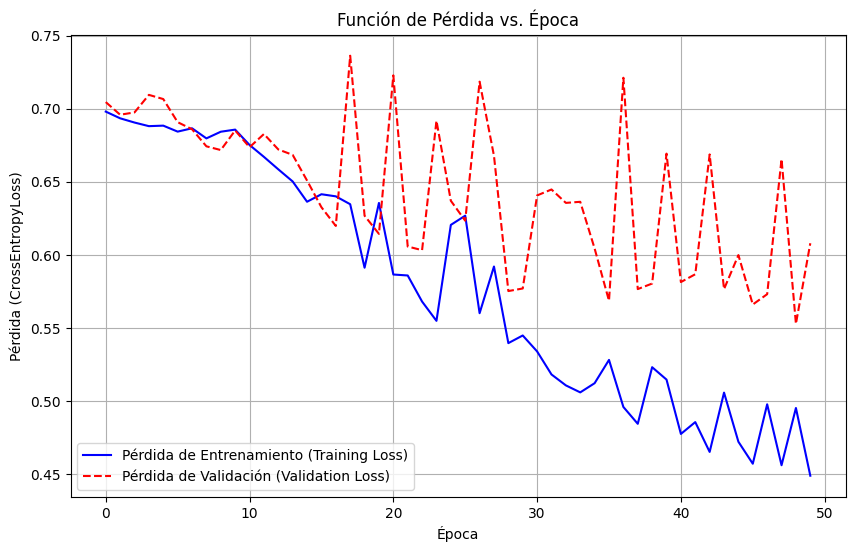

In [ ]:
## --- CÓDIGO DE VISUALIZACIÓN ---

plt.figure(figsize=(10, 6))

# Trazar la pérdida de entrenamiento
plt.plot(train_losses, label='Pérdida de Entrenamiento (Training Loss)', color='blue')

# Trazar la pérdida de validación
plt.plot(val_losses, label='Pérdida de Validación (Validation Loss)', color='red', linestyle='--')

# Configuración del gráfico
plt.title('Función de Pérdida vs. Época')
plt.xlabel('Época')
plt.ylabel('Pérdida (CrossEntropyLoss)')
plt.legend()
plt.grid(True)
plt.show()

## Evaluación

Iniciando evaluación...

🎯 Accuracy Global: 70.00%

📊 Reporte de Clasificación:
              precision    recall  f1-score   support

  Incorrecto       0.58      0.88      0.70         8
    Correcto       0.88      0.58      0.70        12

    accuracy                           0.70        20
   macro avg       0.73      0.73      0.70        20
weighted avg       0.76      0.70      0.70        20



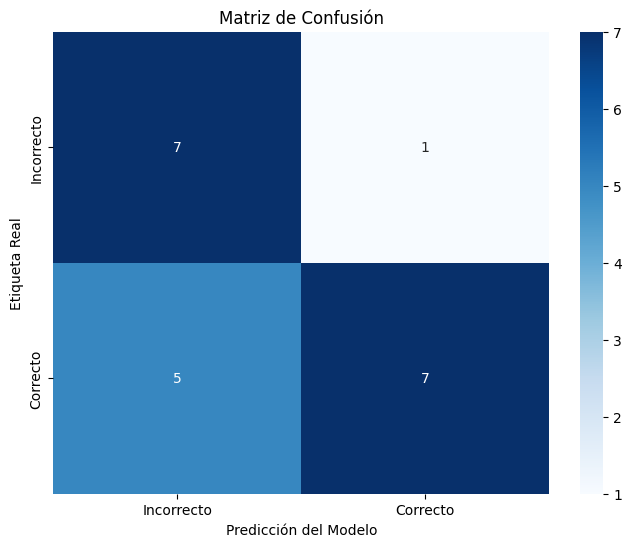

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate_model(model, dataloader, device, class_names=['Incorrecto', 'Correcto']):
    """
    Evalúa el modelo y genera métricas y gráficos detallados.
    """
    model.eval() # 1. Apaga Dropout y BatchNormalization
    
    all_preds = []
    all_labels = []
    
    print("Iniciando evaluación...")
    
    with torch.no_grad(): # 2. Desactiva el cálculo de gradientes (ahorra memoria)
        for batch in dataloader:
            # Manejo flexible: si el dataloader devuelve mask o no
            if len(batch) == 3:
                inputs, labels, mask = batch
                inputs, labels, mask = inputs.to(device), labels.to(device), mask.to(device)
                # Si tu modelo requiere mask explícita:
                # outputs = model(inputs, mask) 
                # Si tu modelo tiene auto-masking:
                outputs = model(inputs) 
            else:
                inputs, labels = batch
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs) # El modelo genera la máscara internamente

            # Obtener la clase predicha (el índice con mayor valor)
            _, preds = torch.max(outputs, 1)
            
            # Guardar predicciones y etiquetas reales en CPU
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- CÁLCULO DE MÉTRICAS ---
    
    # 3. Accuracy Global
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n🎯 Accuracy Global: {acc*100:.2f}%")
    
    # 4. Reporte Detallado (Precision, Recall, F1)
    print("\n📊 Reporte de Clasificación:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # 5. Matriz de Confusión Visual
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.title('Matriz de Confusión')
    plt.show()

# --- EJECUCIÓN ---
# Asegúrate de tener definido 'test_dataloader' con datos que el modelo NO ha visto
evaluate_model(model, val_dataloader, device)

# Experimentos

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
import numpy as np
import copy # Para guardar los mejores pesos (restore_best_weights)

def run_kfold_experiment_pytorch(model_class, model_params, X_full, y_full, 
                                 epochs, batch_size, lr=0.001, n_splits=5, patience=None, device='cpu'):
    """
    Ejecuta validación cruzada K-Fold para un modelo PyTorch.
    
    Args:
        model_class: La clase del modelo (ej. STGCN_Model_Refactored).
        model_params: Diccionario con argumentos para __init__ (ej. {'num_classes': 2, ...}).
        X_full, y_full: Tensores o arrays de datos completos.
        epochs, batch_size, lr: Hiperparámetros.
        n_splits: Número de folds.
        patience: Paciencia para Early Stopping (None para desactivar).
        device: 'cuda' o 'cpu'.
    
    Returns:
        mean_acc, std_acc, fold_histories
    """
    
    # Asegurarse de que X e y sean arrays de Numpy para KFold
    if isinstance(X_full, torch.Tensor): X_full = X_full.cpu().numpy()
    if isinstance(y_full, torch.Tensor): y_full = y_full.cpu().numpy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_accuracies = []
    fold_histories = [] # Lista de diccionarios con las pérdidas/acc por época
    
    print(f"🚀 Iniciando K-Fold ({n_splits} splits) en {device}...")
    print("===" * 20)

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_full)):
        print(f"\n🔄 Pliegue {fold_idx + 1}/{n_splits}")
        
        # 1. Preparar Datos para este Pliegue
        X_train_fold = torch.tensor(X_full[train_index], dtype=torch.float32)
        y_train_fold = torch.tensor(y_full[train_index], dtype=torch.long)
        X_val_fold = torch.tensor(X_full[val_index], dtype=torch.float32)
        y_val_fold = torch.tensor(y_full[val_index], dtype=torch.long)
        
        train_dataset = TensorDataset(X_train_fold, y_train_fold)
        val_dataset = TensorDataset(X_val_fold, y_val_fold)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # 2. Reinicializar Modelo y Optimizador (IMPORTANTE: Modelo nuevo cada fold)
        model = model_class(**model_params).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        # Diccionario para guardar historia de este fold (estilo Keras)
        history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
        
        # Variables para Early Stopping
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_weights = None
        
        # 3. Bucle de Entrenamiento
        for epoch in range(epochs):
            # --- TRAIN ---
            model.train()
            train_loss_acc = 0
            correct_train = 0
            total_train = 0
            
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                optimizer.zero_grad()
                outputs = model(X_batch) # El modelo maneja masking internamente
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                
                train_loss_acc += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_train += (predicted == y_batch).sum().item()
                total_train += y_batch.size(0)
            
            epoch_train_loss = train_loss_acc / len(train_loader.dataset)
            epoch_train_acc = correct_train / total_train
            
            # --- VALIDATION ---
            model.eval()
            val_loss_acc = 0
            correct_val = 0
            total_val = 0
            
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    
                    val_loss_acc += loss.item() * X_batch.size(0)
                    _, predicted = torch.max(outputs, 1)
                    correct_val += (predicted == y_batch).sum().item()
                    total_val += y_batch.size(0)
            
            epoch_val_loss = val_loss_acc / len(val_loader.dataset)
            epoch_val_acc = correct_val / total_val
            
            # Guardar en historial
            history['loss'].append(epoch_train_loss)
            history['acc'].append(epoch_train_acc)
            history['val_loss'].append(epoch_val_loss)
            history['val_acc'].append(epoch_val_acc)
            
            # --- EARLY STOPPING LOGIC ---
            if patience is not None:
                if epoch_val_loss < best_val_loss:
                    best_val_loss = epoch_val_loss
                    patience_counter = 0
                    # Guardar los mejores pesos en memoria
                    best_model_weights = copy.deepcopy(model.state_dict())
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"    ⏹️ Early stopping en época {epoch+1}")
                        # Restaurar mejores pesos
                        if best_model_weights:
                            model.load_state_dict(best_model_weights)
                        break
        
        # Fin del fold
        print(f"    ✅ Finalizado. Acc Val: {epoch_val_acc:.4f} | Loss Val: {epoch_val_loss:.4f}")
        fold_accuracies.append(epoch_val_acc) # Usar la del último epoch (o el mejor si hubo restore)
        fold_histories.append(history)

    # Métricas Finales
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    
    print("===" * 20)
    print(f"📊 Resultados K-Fold:")
    print(f"| Accuracy Medio: {mean_acc:.4f}")
    print(f"| Desviación Std: {std_acc:.4f}")
    
    return mean_acc, std_acc, fold_histories

In [56]:
import matplotlib.pyplot as plt

def plot_kfold_history_pytorch(fold_histories, title='Métricas K-Fold ST-GCN'):
    """Grafica Loss y Accuracy promedio con sombra de desviación estándar."""
    
    if not fold_histories:
        print("Error: No hay historias para graficar.")
        return

    # Encontrar la longitud mínima (por si hubo Early Stopping en tiempos distintos)
    # Cortamos todas las gráficas a la longitud del entrenamiento más corto
    # Opcional: Podrías rellenar con NaNs, pero cortar es más limpio para visualizar.
    min_epochs = min(len(h['loss']) for h in fold_histories)
    
    print(f"Graficando las primeras {min_epochs} épocas comunes...")

    # Crear arrays para promedios
    metrics = ['loss', 'val_loss', 'acc', 'val_acc']
    data = {m: np.zeros((len(fold_histories), min_epochs)) for m in metrics}

    for i, history in enumerate(fold_histories):
        for m in metrics:
            data[m][i, :] = history[m][:min_epochs]

    # Calcular medias y desviaciones
    means = {m: np.mean(data[m], axis=0) for m in metrics}
    stds = {m: np.std(data[m], axis=0) for m in metrics}
    
    epochs_range = range(1, min_epochs + 1)

    # --- PLOT 1: LOSS ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Train Loss
    plt.plot(epochs_range, means['loss'], label='Train Loss', color='blue')
    plt.fill_between(epochs_range, means['loss'] - stds['loss'], means['loss'] + stds['loss'], color='blue', alpha=0.1)
    # Val Loss
    plt.plot(epochs_range, means['val_loss'], label='Val Loss', color='red')
    plt.fill_between(epochs_range, means['val_loss'] - stds['val_loss'], means['val_loss'] + stds['val_loss'], color='red', alpha=0.1)
    
    plt.title(f'{title} - Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 2: ACCURACY ---
    plt.subplot(1, 2, 2)
    # Train Acc
    plt.plot(epochs_range, means['acc'], label='Train Acc', color='blue')
    plt.fill_between(epochs_range, means['acc'] - stds['acc'], means['acc'] + stds['acc'], color='blue', alpha=0.1)
    # Val Acc
    plt.plot(epochs_range, means['val_acc'], label='Val Acc', color='green')
    plt.fill_between(epochs_range, means['val_acc'] - stds['val_acc'], means['val_acc'] + stds['val_acc'], color='green', alpha=0.1)
    
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

## EXP-ST-GCN-01
Evaluación del modelo con K-Fold

In [20]:
# 1. Definir los parámetros del modelo en un diccionario
# Esto es necesario para pasar los argumentos al __init__ dentro del bucle
model_params = {
    'num_classes': 2,
    'A_partitions': A_PARTITIONS  # Asegúrate de tener tu matriz A definida
}

# 2. Definir tus datos (Suponiendo que ya tienes X_train y y_train)
# X_train shape: (Num_muestras, T, 66)
# y_train shape: (Num_muestras,)

# 3. Ejecutar el experimento
mean_acc, std_acc, histories = run_kfold_experiment_pytorch(
    model_class=STGCN_Model, # Pasamos la CLASE, no una instancia
    model_params=model_params,          # Argumentos para instanciarla
    X_full=X_tensor,                     # Tus datos
    y_full=y_tensor,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,                        # Early Stopping activado
    device=device
)

# 4. Graficar
plot_kfold_history_pytorch(histories, title="ST-GCN Validación Cruzada")

🚀 Iniciando K-Fold (5 splits) en cuda...

🔄 Pliegue 1/5


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 10.12 MiB is free. Process 6823 has 14.63 GiB memory in use. Process 257551 has 102.00 MiB memory in use. Of the allocated memory 1.60 MiB is allocated by PyTorch, and 406.00 KiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## EXP-ST-GCN-02

In [23]:
import torch
import numpy as np

# Cargamos los numpy arrays guardados
X_correct = np.load('./Data/Processed/mixed_correct_push_ups_landmarks.npy')
X_incorrect = np.load('./Data/Processed/mixed_wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

# Convertir a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

🚀 Iniciando K-Fold (5 splits) en cuda...

🔄 Pliegue 1/5
    ✅ Finalizado. Acc Val: 0.8750 | Loss Val: 0.2721

🔄 Pliegue 2/5
    ✅ Finalizado. Acc Val: 0.8250 | Loss Val: 0.2957

🔄 Pliegue 3/5
    ✅ Finalizado. Acc Val: 0.7500 | Loss Val: 0.3905

🔄 Pliegue 4/5
    ✅ Finalizado. Acc Val: 0.8500 | Loss Val: 0.2970

🔄 Pliegue 5/5
    ✅ Finalizado. Acc Val: 0.9750 | Loss Val: 0.1020
📊 Resultados K-Fold:
| Accuracy Medio: 0.8550
| Desviación Std: 0.0731
Graficando las primeras 100 épocas comunes...


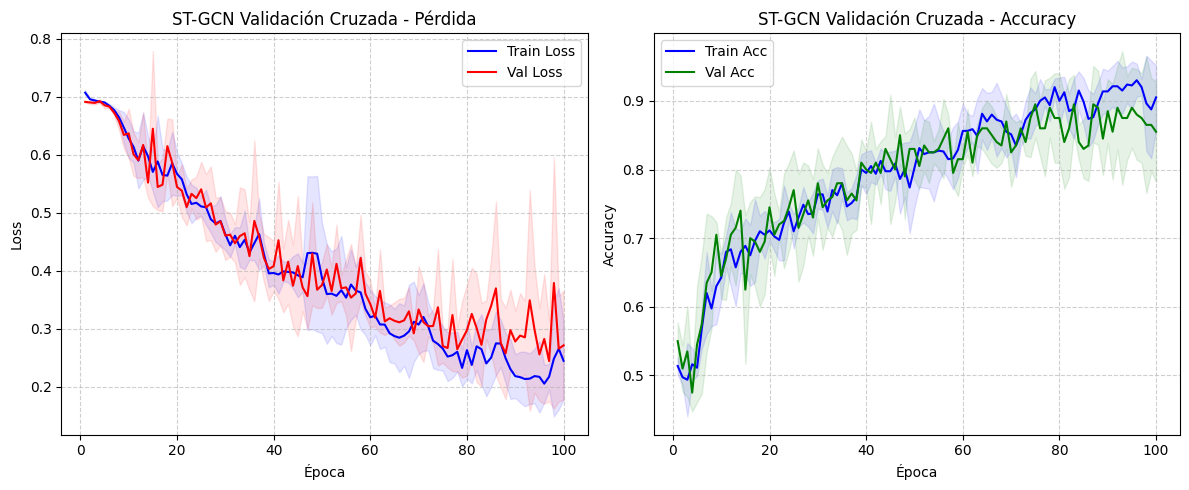

In [24]:
# 1. Definir los parámetros del modelo en un diccionario
# Esto es necesario para pasar los argumentos al __init__ dentro del bucle
model_params = {
    'num_classes': 2,
    'A_partitions': A_PARTITIONS  
}

# 2. Definir tus datos (Suponiendo que ya tienes X_train y y_train)
# X_train shape: (Num_muestras, T, 66)
# y_train shape: (Num_muestras,)

# 3. Ejecutar el experimento
mean_acc, std_acc, histories = run_kfold_experiment_pytorch(
    model_class=STGCN_Model, # Pasamos la CLASE, no una instancia
    model_params=model_params,          # Argumentos para instanciarla
    X_full=X_tensor,                     # Tus datos
    y_full=y_tensor,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,                        # Early Stopping activado
    device=device
)

# 4. Graficar
plot_kfold_history_pytorch(histories, title="ST-GCN Validación Cruzada")

In [ ]:
import torch
import gc

# 1. Borrar variables que puedan estar ocupando memoria en el notebook
# (Si tienes variables globales de los experimentos anteriores, elimínalas)
# Por ejemplo, si tienes 'mejor_modelo', 'histories', etc. que no necesites:
# del mejor_modelo 

# 2. Recolección de basura de Python (elimina referencias huérfanas)
gc.collect()

# 3. Vaciar la caché de la GPU de PyTorch
torch.cuda.empty_cache()

print("🧹 Memoria de GPU liberada.")
print(f"Memoria reservada actual: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

## EXP ST-GCN-03

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

def train_final_model_pytorch(model_class, model_params, X_full, y_full, 
                              epochs=100, batch_size=32, lr=0.001, device='cpu'):
    """
    Entrena un modelo PyTorch con el dataset completo (sin validación cruzada).
    Ideal para generar el modelo final para producción o inferencia.
    
    Args:
        model_class: La clase del modelo (ej. STGCN_Model_Refactored).
        model_params: Diccionario con argumentos para __init__.
        X_full, y_full: Datos de entrenamiento completos.
        epochs: Número de épocas (por defecto 100).
        batch_size, lr: Hiperparámetros.
        device: 'cuda' o 'cpu'.
    
    Returns:
        model: El modelo entrenado.
    """
    
    print(f"🚀 Iniciando entrenamiento final en {device} por {epochs} épocas...")
    print("===" * 20)

    # 1. Preparar Datos (Convertir a Tensores)
    # Si ya son tensores, usar .clone().detach() o mantenerlos; si son numpy, convertir.
    if not isinstance(X_full, torch.Tensor):
        X_tensor = torch.tensor(X_full, dtype=torch.float32)
    else:
        X_tensor = X_full.float()
        
    if not isinstance(y_full, torch.Tensor):
        y_tensor = torch.tensor(y_full, dtype=torch.long)
    else:
        y_tensor = y_full.long()

    # Crear Dataset y DataLoader para el conjunto completo
    full_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

    # 2. Inicializar Modelo y Optimizador
    model = model_class(**model_params).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 3. Bucle de Entrenamiento
    for epoch in range(epochs):
        model.train()
        train_loss_accum = 0
        correct_train = 0
        total_train = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(X_batch) 
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Métricas
            train_loss_accum += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == y_batch).sum().item()
            total_train += y_batch.size(0)
        
        # Calcular medias de la época
        epoch_loss = train_loss_accum / len(train_loader.dataset)
        epoch_acc = correct_train / total_train
        
        # Imprimir progreso cada 10 épocas (o la última)
        if (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
            print(f"Epoca {epoch + 1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    print("===" * 20)
    print("✅ Entrenamiento completado.")
    
    return model

In [58]:
# Definir parámetros
params = {
    'num_classes': 2,
    'A_partitions': A_PARTITIONS # Asegúrate de tener esto definido
}

# Entrenar
analysis_model = train_final_model_pytorch(
    model_class=STGCN_Model,
    model_params=params,
    X_full=X_tensor, # Tus datos numpy o tensores
    y_full=y_tensor,
    epochs=100,     # Forzamos 100 épocas
    batch_size=8,
    device='cuda' 
)


🚀 Iniciando entrenamiento final en cuda por 100 épocas...
Epoca 10/100 | Loss: 0.6642 | Acc: 0.6600
Epoca 20/100 | Loss: 0.6223 | Acc: 0.6500
Epoca 30/100 | Loss: 0.5722 | Acc: 0.7100
Epoca 40/100 | Loss: 0.4498 | Acc: 0.7600
Epoca 50/100 | Loss: 0.3751 | Acc: 0.8200
Epoca 60/100 | Loss: 0.3107 | Acc: 0.8700
Epoca 70/100 | Loss: 0.2592 | Acc: 0.9000
Epoca 80/100 | Loss: 0.3554 | Acc: 0.8300
Epoca 90/100 | Loss: 0.2388 | Acc: 0.9500
Epoca 100/100 | Loss: 0.2306 | Acc: 0.9100
✅ Entrenamiento completado.


In [60]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.losses import binary_crossentropy
import torch
import torch.nn as nn

# --- B. Calcular la Pérdida por Muestra en X_train ---

print("Calculando la pérdida individual por muestra...")

# 1. Obtener las predicciones del modelo 
# Asegúrate de usar no_grad() para ahorrar memoria ya que no estamos entrenando
with torch.no_grad():
    output = analysis_model(X_tensor.float().to(device)) 
    
    # Aplicar Softmax para obtener probabilidades
    y_pred_proba = nn.Softmax(dim=1)(output)

    # La clase predicha es el índice con la probabilidad más alta
    predicted_class = torch.argmax(y_pred_proba, dim=1)

    # --- CORRECCIÓN AQUÍ ---
    # Convertimos el tensor de GPU a un array de NumPy en CPU
    # .detach() quita el tensor del grafo de gradientes
    # .cpu() mueve los datos de la GPU a la CPU
    # .numpy() lo convierte a formato numpy estándar
    y_pred_np = predicted_class.detach().cpu().numpy()

# Convertir y_train de la forma (80,) a la forma (80, 1)
y_reshaped = np.expand_dims(y_tensor.numpy(), axis=-1)

# 2. Convertir a tensores para el cálculo de la pérdida en TensorFlow
y_tensor_tf = tf.convert_to_tensor(y_reshaped, dtype=tf.float32)

# Usamos la versión numpy que creamos arriba
y_pred_tf = tf.convert_to_tensor(y_pred_np, dtype=tf.float32) 

# NOTA IMPORTANTE: Si tu salida es Softmax (2 columnas) y tu y_tensor_tf es (N, 1),
# binary_crossentropy de Keras podría dar resultados inesperados por broadcasting.
# Si tu problema es binario y usas Softmax, generalmente deberías tomar solo la probabilidad
# de la clase positiva (columna 1) para usar binary_crossentropy.
# Ejemplo: y_pred_tf = tf.convert_to_tensor(y_pred_proba_np[:, 1], dtype=tf.float32)

# 3. Calcular la Binary Crossentropy (pérdida) para cada muestra
losses_per_sample = binary_crossentropy(y_tensor_tf, y_pred_tf)
losses_np = losses_per_sample.numpy()

# --- C. Identificar los Índices Ruidosos ---
# (El resto del código sigue igual...)

# 1. Definir el porcentaje de ruido a buscar
PERCENTAJE_RUIDO = 0.05
num_total_samples = len(X_tensor)
num_noisy_samples = int(num_total_samples * PERCENTAJE_RUIDO)

# 2. Obtener los índices de las muestras ordenadas por pérdida
noisy_indices = np.argsort(losses_np)[::-1]

# 3. Seleccionar los top N índices más ruidosos
top_noisy_indices_X = noisy_indices[:num_noisy_samples]

# --- D. Resultados ---
print("\n" + "="*50)
print(f"ANÁLISIS DE RUIDO COMPLETADO ({num_total_samples} muestras en X_train)")
print(f"Se han identificado los {num_noisy_samples} índices ({PERCENTAJE_RUIDO*100}%) más ruidosos.")
print("="*50)

print("Top 5% de Muestras Ruidosas (Índice y Pérdida):")
for i in top_noisy_indices_X:
    print(f"Índice en X_train: {i} | Pérdida: {losses_np[i]:.4f} | Etiqueta Real: {y_tensor[i]}")
print("="*50)

Calculando la pérdida individual por muestra...


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(100, 1), output.shape=(100,)

In [40]:
# Versión 100% PyTorch
criterion = nn.CrossEntropyLoss(reduction='none') # 'none' devuelve la pérdida individual por muestra

with torch.no_grad():
    output = analysis_model(X_tensor.float().to(device))
    y_target = y_tensor.long().to(device) # Asegúrate que sea LongTensor para CrossEntropy
    
    # Calcular pérdidas individuales
    losses_tensor = criterion(output, y_target)
    
    # Llevar a numpy para ordenar
    losses_np = losses_tensor.cpu().numpy()

OutOfMemoryError: CUDA out of memory. Tried to allocate 258.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 112.12 MiB is free. Process 6823 has 14.63 GiB memory in use. Of the allocated memory 13.66 GiB is allocated by PyTorch, and 856.59 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)